# Part 8 — Gratings vs. Natural Scenes

Asks whether the transient peak in cross-mouse representational consistency
is a general property of V1 stimulus processing or is specific to natural
images. Static grating conditions (orientation × spatial frequency) serve as
the comparison: if gratings produce a flatter temporal profile and lower peak
consistency (after noise-ceiling normalisation), the natural-scene result
reflects something specific about the representational content of naturalistic
stimuli rather than a generic response gain modulation.

Noise-ceiling normalisation is essential for fair comparison because gratings
have very high per-condition reliability (mean NC ≈ 0.99) while natural
scenes span a broader range; expressing both as % of noise ceiling removes
the reliability confound.

**Depends on:** `responses.h5` (static-gratings tensors, VISp),
               `noise_ceiling_gratings_VISp.npy`,
               `part3_outputs.npz` (natural-scenes reference curves),
               `manifest.json`
**Outputs saved:** none (terminal notebook)

In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

SEED = 42

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')
COL_NS  = 'steelblue'    # natural scenes
COL_GR  = 'darkorange'   # gratings
COL_FIT = 'firebrick'    # peak annotations / statistics
COL_REF = 'dimgray'      # reference lines / baselines


colors  = apply_plot_style()
COL_NS  = colors["COL_NS"]
COL_GR  = colors["COL_GR"]
COL_FIT = colors["COL_FIT"]
COL_REF = colors["COL_REF"]

In [9]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
SESSION_IDS      = manifest['selected_session_ids_visp']
N_CONDITIONS     = manifest['n_grating_conditions']     # 30
N_IMAGES         = manifest['n_images']                 # 118

nc_gratings  = np.load(ARCHIVE_DIR / 'noise_ceiling_gratings_VISp.npy')
mean_nc_gr   = nc_gratings.mean(0)       # (30,)
scalar_nc_gr = mean_nc_gr.mean()         # scalar
print(f'Gratings NC: mean = {scalar_nc_gr:.4f}, '
      f'range [{nc_gratings.min():.3f}, {nc_gratings.max():.3f}]')

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms_ns        = p3['times_ms']
mean_c_ns          = p3['mean_c']
window_centers_ms  = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS    = float(p3['window_width_ms'])
peak_t_ns          = float(p3['peak_t'])
peak_c_ns          = float(p3['peak_c'])
baseline_ns        = float(p3['baseline'])
sustained_floor_ns = float(p3['sustained_floor'])

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
mean_nc_ns = p1['noise_ceiling'].mean()

SLIDE_START_MS = int(times_ms_ns.min())
SLIDE_END_MS   = int(times_ms_ns.max()) + 1

print(f'Natural scenes: peak = {peak_c_ns:.4f} at {peak_t_ns:.0f} ms, '
      f'mean NC = {mean_nc_ns:.4f}')
print(f'Sliding window: {len(window_centers_ms)} windows, '
      f'width = {WINDOW_WIDTH_MS:.0f} ms')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Gratings NC: mean = 0.9917, range [0.949, 0.998]
Natural scenes: peak = 0.3065 at 100 ms, mean NC = 0.9778
Sliding window: 43 windows, width = 25 ms


In [10]:
print('Loading static-gratings tensors...')
grating_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'static_gratings/VISp/{sid}']
        grating_tensors[sid] = grp['tensor'][:]   # (30, n_units, 95)
print(f'Loaded {len(grating_tensors)} sessions.')

Loading static-gratings tensors...
Loaded 32 sessions.


## 8.1 — Fixed-window (0–250 ms) consistency for gratings vs. natural scenes

As a baseline comparison, compute the scalar mean consistency in the
0–250 ms window used throughout Parts 1–2 for both stimuli.

In [11]:
def fixed_window_consistency_gr(t_lo=0, t_hi=250):
    mats = [window_response(grating_tensors[sid], t_lo, t_hi)
            for sid in SESSION_IDS]
    sims = compute_similarity_matrices(mats)
    c,_,_ = per_image_consistency(sims)
    return c.mean(), c

c_gr_scalar, c_gr_per_cond = fixed_window_consistency_gr()
c_ns_scalar = mean_c_ns[(times_ms_ns >= 0) & (times_ms_ns <= 250)].mean()

print(f'\nFixed window (0–250 ms):')
print(f'  Natural scenes mean consistency: {c_ns_scalar:.4f}')
print(f'  Gratings mean consistency:       {c_gr_scalar:.4f}')
print(f'  Gratings NC (mean):              {scalar_nc_gr:.4f}')
print(f'  Gratings as % of NC:             {c_gr_scalar / scalar_nc_gr * 100:.1f}%')
print(f'  Natural scenes NC (mean):        {mean_nc_ns:.4f}')
print(f'  Nat. scenes as % of NC:          {c_ns_scalar / mean_nc_ns * 100:.1f}%')


Fixed window (0–250 ms):
  Natural scenes mean consistency: 0.1830
  Gratings mean consistency:       0.7198
  Gratings NC (mean):              0.9917
  Gratings as % of NC:             72.6%
  Natural scenes NC (mean):        0.9778
  Nat. scenes as % of NC:          18.7%


## 8.2 — Sliding-window temporal profiles

The same 25 ms / 10 ms-step sliding window used in Part 3 is applied to
static-gratings data. At each window the per-condition mean consistency is
the scalar mean across all 30 grating conditions (analogous to the per-image
mean across 118 natural-scene images). The resulting temporal profile is
compared directly to the natural-scenes curve from Part 3.

In [12]:
print('Computing sliding-window consistency for gratings...')
sliding_gr = {}

for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2
    mats = [window_response(grating_tensors[sid], t_lo, t_hi)
            for sid in SESSION_IDS]
    sims = compute_similarity_matrices(mats)
    c, _, _ = per_image_consistency(sims)
    sliding_gr[t_ms] = c.mean()

times_ms_gr = np.array(sorted(sliding_gr))
mean_c_gr   = np.array([sliding_gr[t] for t in times_ms_gr])

peak_idx_gr  = np.argmax(mean_c_gr[(times_ms_gr >= 0) & (times_ms_gr <= 250)])
valid_gr     = mean_c_gr[(times_ms_gr >= 0) & (times_ms_gr <= 250)]
peak_c_gr    = valid_gr.max()
peak_t_gr    = times_ms_gr[(times_ms_gr >= 0) & (times_ms_gr <= 250)][np.argmax(valid_gr)]
baseline_gr  = mean_c_gr[times_ms_gr < 0].mean() if (times_ms_gr < 0).any() else 0.0
sust_mask_gr = (times_ms_gr >= 220) & (times_ms_gr <= 250)
sust_gr      = mean_c_gr[sust_mask_gr].mean() if sust_mask_gr.any() else 0.0
ts_ratio_gr  = peak_c_gr / (sust_gr + 1e-8)

print(f'\nGratings temporal profile:')
print(f'  Pre-stimulus baseline: {baseline_gr:.4f}')
print(f'  Peak: {peak_c_gr:.4f} at {peak_t_gr:.0f} ms')
print(f'  Sustained (220–250 ms): {sust_gr:.4f}')
print(f'  T/S ratio: {ts_ratio_gr:.2f}×')

# Natural-scene T/S for comparison (from Part 3 outputs)
sust_mask_ns = (times_ms_ns >= 220) & (times_ms_ns <= 250)
sust_ns      = mean_c_ns[sust_mask_ns].mean()
ts_ratio_ns  = peak_c_ns / (sust_ns + 1e-8)
print(f'\nNatural scenes T/S ratio (from Part 3): {ts_ratio_ns:.2f}×')

Computing sliding-window consistency for gratings...

Gratings temporal profile:
  Pre-stimulus baseline: -0.0002
  Peak: 0.6797 at 250 ms
  Sustained (220–250 ms): 0.6769
  T/S ratio: 1.00×

Natural scenes T/S ratio (from Part 3): 1.68×


## 8.3 — Noise-ceiling normalised curves

Expressing both curves as a fraction of their respective noise ceilings
enables a fair comparison of representational consistency on a common scale.
NC_ns is the mean across images and sessions from Part 1;
NC_gr is the mean across conditions and sessions from the precomputed file.

In [13]:
nc_norm_ns = mean_c_ns / (mean_nc_ns + 1e-8)
nc_norm_gr = mean_c_gr / (scalar_nc_gr + 1e-8)

# Percentage-ceiling statistics
pct_ceil_ns_peak = (peak_c_ns / mean_nc_ns) * 100
pct_ceil_gr_peak = (peak_c_gr / scalar_nc_gr) * 100

print(f'\nNC-normalised peak:')
print(f'  Natural scenes: {pct_ceil_ns_peak:.1f}% of NC ceiling')
print(f'  Gratings:       {pct_ceil_gr_peak:.1f}% of NC ceiling')


NC-normalised peak:
  Natural scenes: 31.4% of NC ceiling
  Gratings:       68.5% of NC ceiling


---
## Figures

**Fig. 8** — Static gratings produce a weaker and less transient cross-mouse
consistency than natural scenes, even after noise-ceiling normalisation.


Fig. 8A — Raw consistency: natural scenes vs. static gratings

--- times_ms_natural_scenes ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- mean_consistency_natural_scenes ---
shape=(43,)
[ 0.000048  0.000033 -0.000179  0.000444 -0.000164  0.000407  0.001345 -0.000375  0.002349  0.037224  0.094116  0.150619  0.19982   0.255017  0.290623  0.30653   0.305512  0.298245  0.28484
  0.270248]
...[43 elements total]

--- times_ms_gratings ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- mean_consistency_gratings ---
shape=(43,)
[-0.001764 -0.001225  0.003225  0.000462 -0.001672  0.00284   0.00156   0.004747  0.00559   0.111256  0.394548  0.570024  0.64248   0.663125  0.654567  0.648008  0.645152  0.651967  0.66213
  0.67292 ]
...[43 elements total]

--- peak_consistency_natural_scenes ---
0.3065302956139142

--- peak_time_ms_natural_scenes 

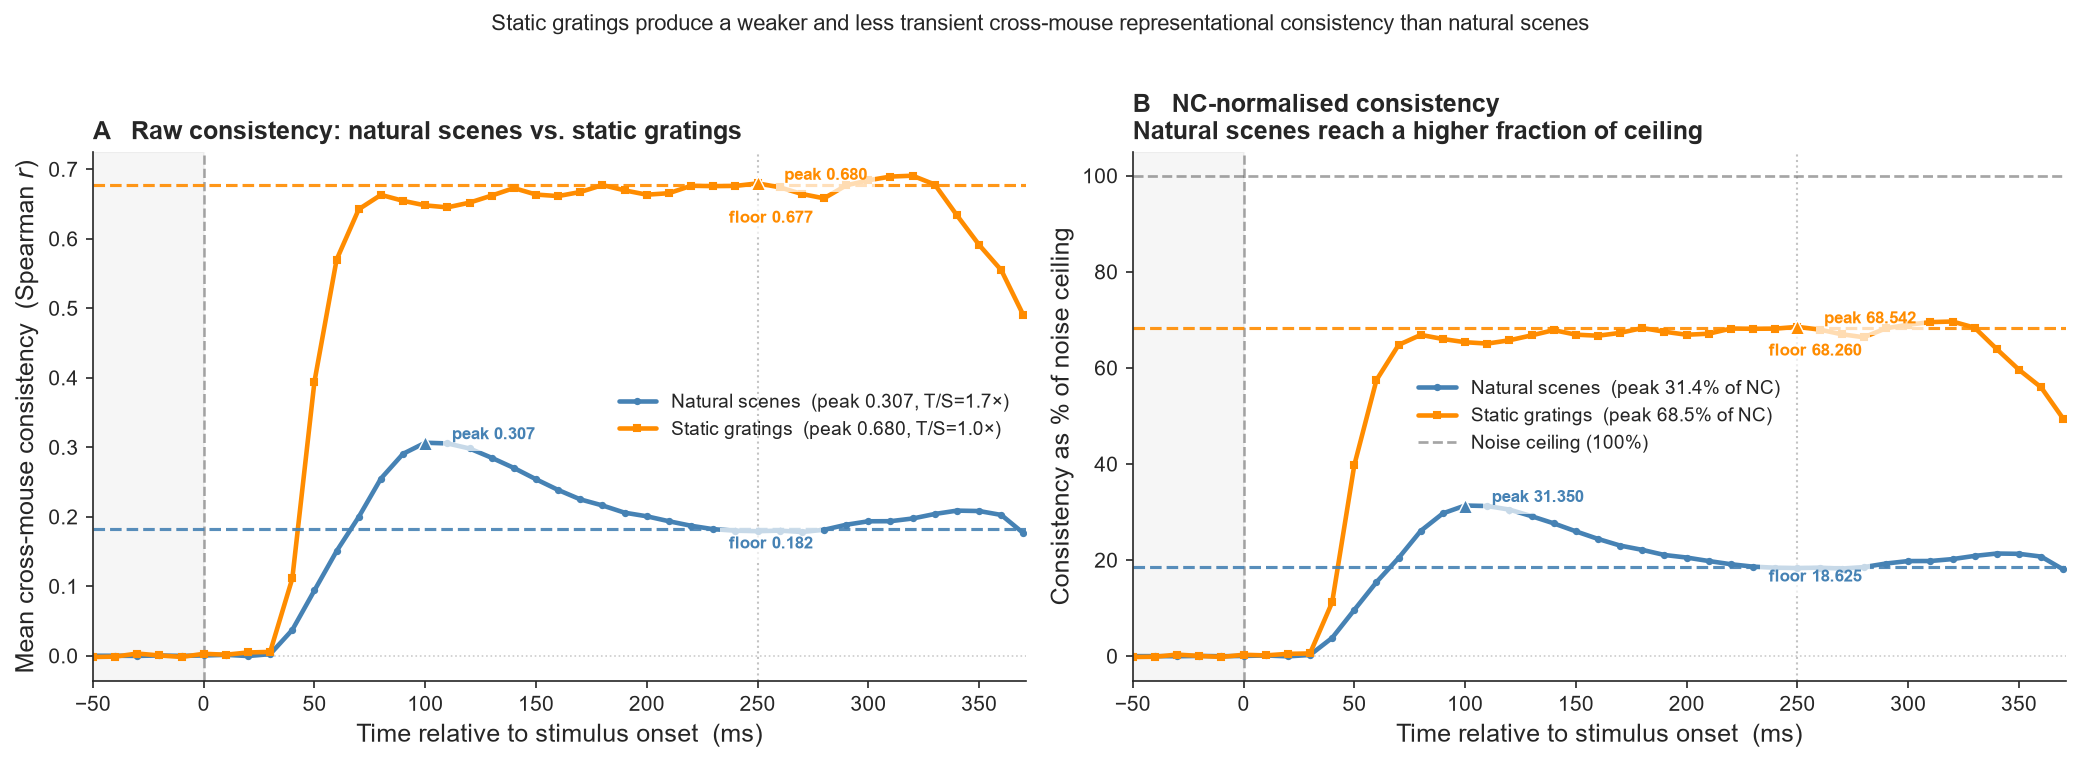

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_bbox = dict(facecolor='white', alpha=0.7, edgecolor='none')

def setup_time_ax(ax):
    ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
    ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.0, alpha=0.4)
    ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)
    ax.set_xlabel('Time relative to stimulus onset  (ms)')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
    ax.spines[['top', 'right']].set_visible(False)


def mark_peak_floor(ax, t, c, peak, sus, color,
                    sustained_lo=220, sustained_hi=250):
    t = np.asarray(t)
    c = np.asarray(c)
    post_mask = (t >= 0) & (t <= 250)
    if np.any(post_mask):
        peak_t = t[post_mask][np.argmax(c[post_mask])]
    else:
        peak_t = t[np.argmax(c)]

    ax.scatter([peak_t], [peak], marker='^', s=48, color=color, zorder=6,
               edgecolor='white', linewidth=0.7)
    ax.text(peak_t + 12, peak,
            f'peak {peak:.3f}',
            fontsize=8, color=color, fontweight='bold',
            ha='left', va='bottom', bbox=text_bbox)

    ax.hlines(sus, SLIDE_START_MS, SLIDE_END_MS,
              colors=color, linewidth=1.5, linestyle='--', alpha=0.9)
    
    offset = max(0.01, abs(peak) * 0.07)
    ax.text((sustained_lo + sustained_hi) / 2 + 2, sus - offset,
            f'floor {sus:.3f}',
            fontsize=8, color=color, fontweight='bold',
            ha='left', va='center', bbox=text_bbox)

# ── Panel A: raw consistency curves ──────────────────────────────────────────
ax = axes[0]
setup_time_ax(ax)
ax.plot(times_ms_ns, mean_c_ns, color=COL_NS, linewidth=2.2,
        marker='o', markersize=2.5,
        label=f'Natural scenes  (peak {peak_c_ns:.3f}, T/S={ts_ratio_ns:.1f}×)')
ax.plot(times_ms_gr, mean_c_gr, color=COL_GR, linewidth=2.2,
        marker='s', markersize=2.5,
        label=f'Static gratings  (peak {peak_c_gr:.3f}, T/S={ts_ratio_gr:.1f}×)')

mark_peak_floor(ax, times_ms_ns, mean_c_ns, peak_c_ns, sust_ns, COL_NS)
mark_peak_floor(ax, times_ms_gr, mean_c_gr, peak_c_gr, sust_gr, COL_GR)

ax.set_ylabel('Mean cross-mouse consistency  (Spearman $r$)')
ax.set_title('A   Raw consistency: natural scenes vs. static gratings',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)

# ── Panel B: NC-normalised curves ────────────────────────────────────────────
ax = axes[1]
setup_time_ax(ax)
ax.plot(times_ms_ns, nc_norm_ns * 100, color=COL_NS, linewidth=2.2,
        marker='o', markersize=2.5,
        label=f'Natural scenes  (peak {pct_ceil_ns_peak:.1f}% of NC)')
ax.plot(times_ms_gr, nc_norm_gr * 100, color=COL_GR, linewidth=2.2,
        marker='s', markersize=2.5,
        label=f'Static gratings  (peak {pct_ceil_gr_peak:.1f}% of NC)')

# NC line reference (100%)
ax.axhline(100, color=COL_REF, linestyle='--', linewidth=1.3, alpha=0.6,
           label='Noise ceiling (100%)')

sust_pct_ns = sust_ns / (mean_nc_ns + 1e-8) * 100
sust_pct_gr = sust_gr / (scalar_nc_gr + 1e-8) * 100
mark_peak_floor(ax, times_ms_ns, nc_norm_ns * 100, pct_ceil_ns_peak,
                                sust_pct_ns, COL_NS)
mark_peak_floor(ax, times_ms_gr, nc_norm_gr * 100, pct_ceil_gr_peak,
                sust_pct_gr, COL_GR)

ax.set_ylabel('Consistency as % of noise ceiling')
ax.set_title('B   NC-normalised consistency\n'
             'Natural scenes reach a higher fraction of ceiling',
             loc='left', fontweight='bold', pad=6)
ax.legend(frameon=False, fontsize=9)

fig.suptitle('Static gratings produce a weaker and less transient '
             'cross-mouse representational consistency than natural scenes',
             fontsize=10.5, y=1.01)

print_figure_data(
    'Fig. 8A — Raw consistency: natural scenes vs. static gratings',
    times_ms_natural_scenes=times_ms_ns,
    mean_consistency_natural_scenes=mean_c_ns,
    times_ms_gratings=times_ms_gr,
    mean_consistency_gratings=mean_c_gr,
    peak_consistency_natural_scenes=peak_c_ns,
    peak_time_ms_natural_scenes=peak_t_ns,
    peak_consistency_gratings=peak_c_gr,
    peak_time_ms_gratings=peak_t_gr,
    ts_ratio_natural_scenes=ts_ratio_ns,
    ts_ratio_gratings=ts_ratio_gr,
)

print_figure_data(
    'Fig. 8B — Noise-ceiling-normalised consistency: natural scenes vs. static gratings',
    times_ms_natural_scenes=times_ms_ns,
    nc_normalised_pct_natural_scenes=nc_norm_ns * 100,
    times_ms_gratings=times_ms_gr,
    nc_normalised_pct_gratings=nc_norm_gr * 100,
    peak_pct_of_nc_natural_scenes=pct_ceil_ns_peak,
    peak_pct_of_nc_gratings=pct_ceil_gr_peak,
    noise_ceiling_natural_scenes=mean_nc_ns,
    noise_ceiling_gratings=scalar_nc_gr,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_gratings_vs_natural_scenes.png', bbox_inches='tight')
plt.show()